In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Matplotlib is building the font cache; this may take a moment.


pandas: 3.0.5
numpy: 2.5.2
scikit-learn: 1.9.0


In [2]:
from ucimlrepo import fetch_ucirepo

# Download the UCI Credit Card Default dataset
credit = fetch_ucirepo(id=350)

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:
# Features
X = credit.data.features.copy()

# Target
y = credit.data.targets.copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (30000, 23)
Target shape: (30000, 1)


In [4]:
display(X.head())

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [5]:
display(y.head())

,Y
0,1
1,1
2,0
3,0
4,0


In [6]:
print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.columns.tolist())

Feature columns:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']

Target column:
['Y']


In [7]:
# Rename variables according to the UCI dataset description
column_mapping = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6"
}

df = X.rename(columns=column_mapping).copy()

# Add target variable
df["default"] = y["Y"].astype(int)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   30000 non-nu

In [9]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

print("\nMissing values by column:")
print(missing_values[missing_values > 0])

Total missing values: 0

Missing values by column:
Series([], dtype: int64)


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 35


In [11]:
default_counts = df["default"].value_counts().sort_index()
default_ratio = df["default"].value_counts(normalize=True).sort_index()

print("Default counts:")
print(default_counts)

print("\nDefault percentages:")
print((default_ratio * 100).round(2))

Default counts:
default
0    23364
1     6636
Name: count, dtype: int64

Default percentages:
default
0    77.88
1    22.12
Name: proportion, dtype: float64


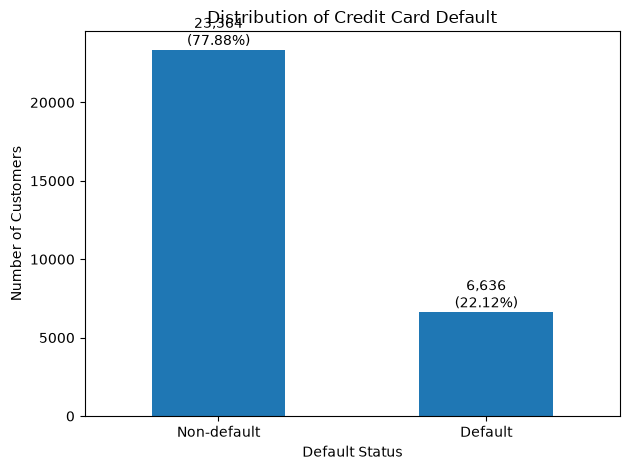

In [18]:

counts = df["default"].value_counts().sort_index()
percentages = df["default"].value_counts(normalize=True).sort_index() * 100

ax = counts.plot(kind="bar")

plt.title("Distribution of Credit Card Default")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Non-default", "Default"], rotation=0)

for i, count in enumerate(counts):
    ax.text(
        i,
        count + 300,
        f"{count:,}\n({percentages.iloc[i]:.2f}%)",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [13]:
print("SEX values:")
print(df["SEX"].value_counts().sort_index())

SEX values:
SEX
1    11888
2    18112
Name: count, dtype: int64


In [14]:
print("EDUCATION values:")
print(df["EDUCATION"].value_counts().sort_index())

EDUCATION values:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


In [15]:
print("MARRIAGE values:")
print(df["MARRIAGE"].value_counts().sort_index())

MARRIAGE values:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [16]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in pay_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


PAY_0:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2:
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3:
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4:
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5:
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6:
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype

In [17]:
numeric_cols = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

display(
    df[numeric_cols]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0


## Initial Data Quality Findings

- The dataset contains 30,000 observations and 23 predictor variables.
- No missing values were identified.
- 35 exact duplicate feature/target combinations were found; these are retained because customer IDs are not included in the feature dataset, so identical rows cannot be confirmed as duplicate customers.
- The target variable is moderately imbalanced:
  - Non-default: 23,364 (77.88%)
  - Default: 6,636 (22.12%)
- Because of the class imbalance, model evaluation should not rely on accuracy alone. Recall, precision, F1-score, ROC-AUC and the confusion matrix will also be considered.